--- Geometric Metadata ---
Image Shape (X, Y, Z): (512, 512, 147)
Voxel Spacing (mm): (np.float32(0.66796875), np.float32(0.66796875), np.float32(3.0))

--- Intensity Metadata ---
Min value (HU): -1024.0
Max value (HU): 2639.0


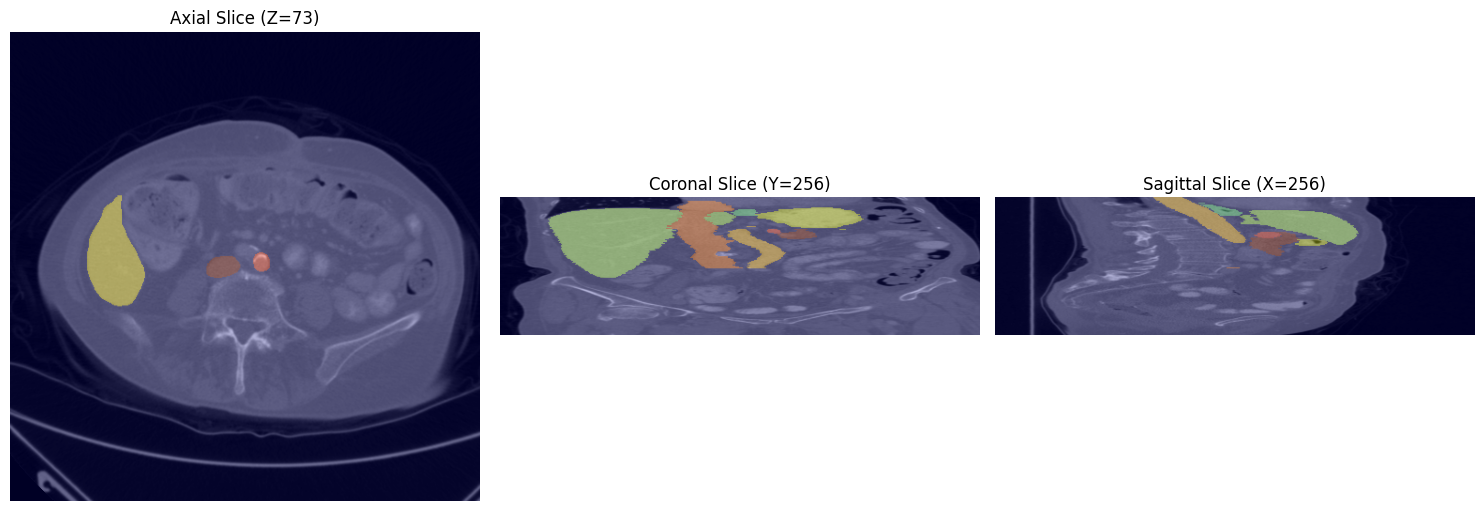

In [5]:
%matplotlib inline
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Define paths to a single image and its corresponding label
data_dir = Path("../data/raw")
img_path = data_dir / "imagesTr" / "img0001.nii.gz"
lbl_path = data_dir / "labelsTr" / "label0001.nii.gz"

# 1. Load NIfTI files
img_nifti = nib.load(img_path)
lbl_nifti = nib.load(lbl_path)

# 2. Extract data as numpy arrays
img_data = img_nifti.get_fdata()
lbl_data = lbl_nifti.get_fdata()

# 3. Print geometric and intensity metadata
print("--- Geometric Metadata ---")
print(f"Image Shape (X, Y, Z): {img_data.shape}")
print(f"Voxel Spacing (mm): {img_nifti.header.get_zooms()}")

print("\n--- Intensity Metadata ---")
print(f"Min value (HU): {np.min(img_data)}")
print(f"Max value (HU): {np.max(img_data)}")

# 4. Multi-planar visualization (Axial, Coronal, Sagittal)
# Find middle slices for each axis
mid_x = img_data.shape[0] // 2
mid_y = img_data.shape[1] // 2
mid_z = img_data.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot Axial slice (Z-axis) with label overlay
axes[0].imshow(img_data[:, :, mid_z].T, cmap="gray", origin="lower")
axes[0].imshow(lbl_data[:, :, mid_z].T, cmap="jet", alpha=0.3, origin="lower")
axes[0].set_title(f"Axial Slice (Z={mid_z})")

# Plot Coronal slice (Y-axis) with label overlay
axes[1].imshow(img_data[:, mid_y, :].T, cmap="gray", origin="lower")
axes[1].imshow(lbl_data[:, mid_y, :].T, cmap="jet", alpha=0.3, origin="lower")
axes[1].set_title(f"Coronal Slice (Y={mid_y})")

# Plot Sagittal slice (X-axis) with label overlay
axes[2].imshow(img_data[mid_x, :, :].T, cmap="gray", origin="lower")
axes[2].imshow(lbl_data[mid_x, :, :].T, cmap="jet", alpha=0.3, origin="lower")
axes[2].set_title(f"Sagittal Slice (X={mid_x})")

# Remove axes formatting for cleaner visualization
for ax in axes:
    ax.axis("off")
    
plt.tight_layout()
plt.show()